In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
def generate_sawtooth_wave(seq_length, num_sequences, step=0.1, frequency=1.0):
    x = np.arange(0, num_sequences * step * seq_length, step)
    y = signal.sawtooth(2 * np.pi * frequency * x)
    return y

In [3]:
class SawtoothDataset(Dataset):
    def __init__(self, data, seq_length):
        self.seq_length = seq_length
        self.data = torch.tensor(data, dtype=torch.float32)
    
    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        return (
            self.data[idx:idx + self.seq_length].unsqueeze(1),
            self.data[idx + self.seq_length]
        )

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1])
        return out.squeeze()

In [5]:
seq_length = 10
num_sequences = 1000
batch_size = 32
learning_rate = 0.001
num_epochs = 20

In [6]:
data = generate_sawtooth_wave(seq_length, num_sequences)

In [7]:
data

array([-1. , -0.8, -0.6, ...,  0.4,  0.6,  0.8])

In [8]:
dataset = SawtoothDataset(data, seq_length)

In [9]:
dataset

In [10]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [11]:
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
model

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [13]:
for epoch in range(num_epochs):
    for inputs, targets in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/20], Loss: 0.1341
Epoch [2/20], Loss: 0.0019
Epoch [3/20], Loss: 0.0854
Epoch [4/20], Loss: 0.0108
Epoch [5/20], Loss: 0.0019
Epoch [6/20], Loss: 0.0004
Epoch [7/20], Loss: 0.0010
Epoch [8/20], Loss: 0.0003
Epoch [9/20], Loss: 0.0004
Epoch [10/20], Loss: 0.2173
Epoch [11/20], Loss: 0.0001
Epoch [12/20], Loss: 0.2131
Epoch [13/20], Loss: 0.0000
Epoch [14/20], Loss: 0.1378
Epoch [15/20], Loss: 0.0001
Epoch [16/20], Loss: 0.2188
Epoch [17/20], Loss: 0.3400
Epoch [18/20], Loss: 0.0003
Epoch [19/20], Loss: 0.0000
Epoch [20/20], Loss: 0.2583


In [26]:
model.eval()
test_inputs = data[:seq_length]
predictions = []

In [27]:
for i in range(1000):
    seq = torch.tensor(test_inputs[-seq_length:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
    with torch.no_grad():
        pred = model(seq).item()
        predictions.append(pred)
        test_inputs = np.append(test_inputs, pred)

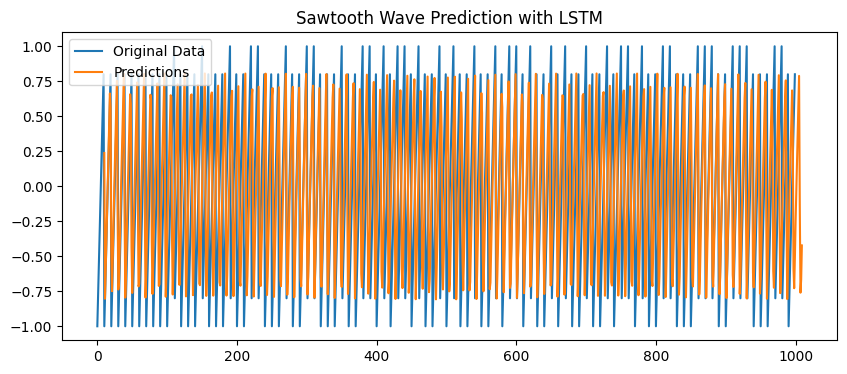

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(data[:1000], label='Original Data')
plt.plot(range(seq_length, seq_length + len(predictions)), predictions, label='Predictions')
plt.legend()
plt.title('Sawtooth Wave Prediction with LSTM')
plt.show()